# Phase 0 — Pipeline QA

Sanity checks on `data/processed/all_specimens.parquet`. Figures are generated by `src/data/qa_figures.py` (so they stay reproducible via `make qa`).

In [1]:
import sys; sys.path.insert(0, '..')
from src.data import qa_figures
df = qa_figures.load()
df.groupby('specimen').agg(
    n=('t', 'size'), dur_s=('t', lambda s: s.max() - s.min()),
    peak_load_kN=('load_kN', 'max'), D_peak_mm=('deflection_mm', 'max'),
    max_FCR_pct=('FCR_pct', 'max'), rate=('loading_rate_mm_per_s', 'first'))

,n,dur_s,peak_load_kN,D_peak_mm,max_FCR_pct,rate
specimen,,,,,,
S1,5674,472.750000,0.179535,7.928797,14.775887,0.016967
S2,8773,731.000000,0.144236,12.313646,17.839533,0.016984
S3,4789,399.000000,0.121045,13.082601,5.807588,0.033207
S4,4319,359.833333,0.060032,11.763399,9.570765,0.033187


## Per-specimen traces
Load should rise then drop at fracture; ΔR/R₀ should show the steep early rise, the saturation plateau, then features near the load peak (dashed line).

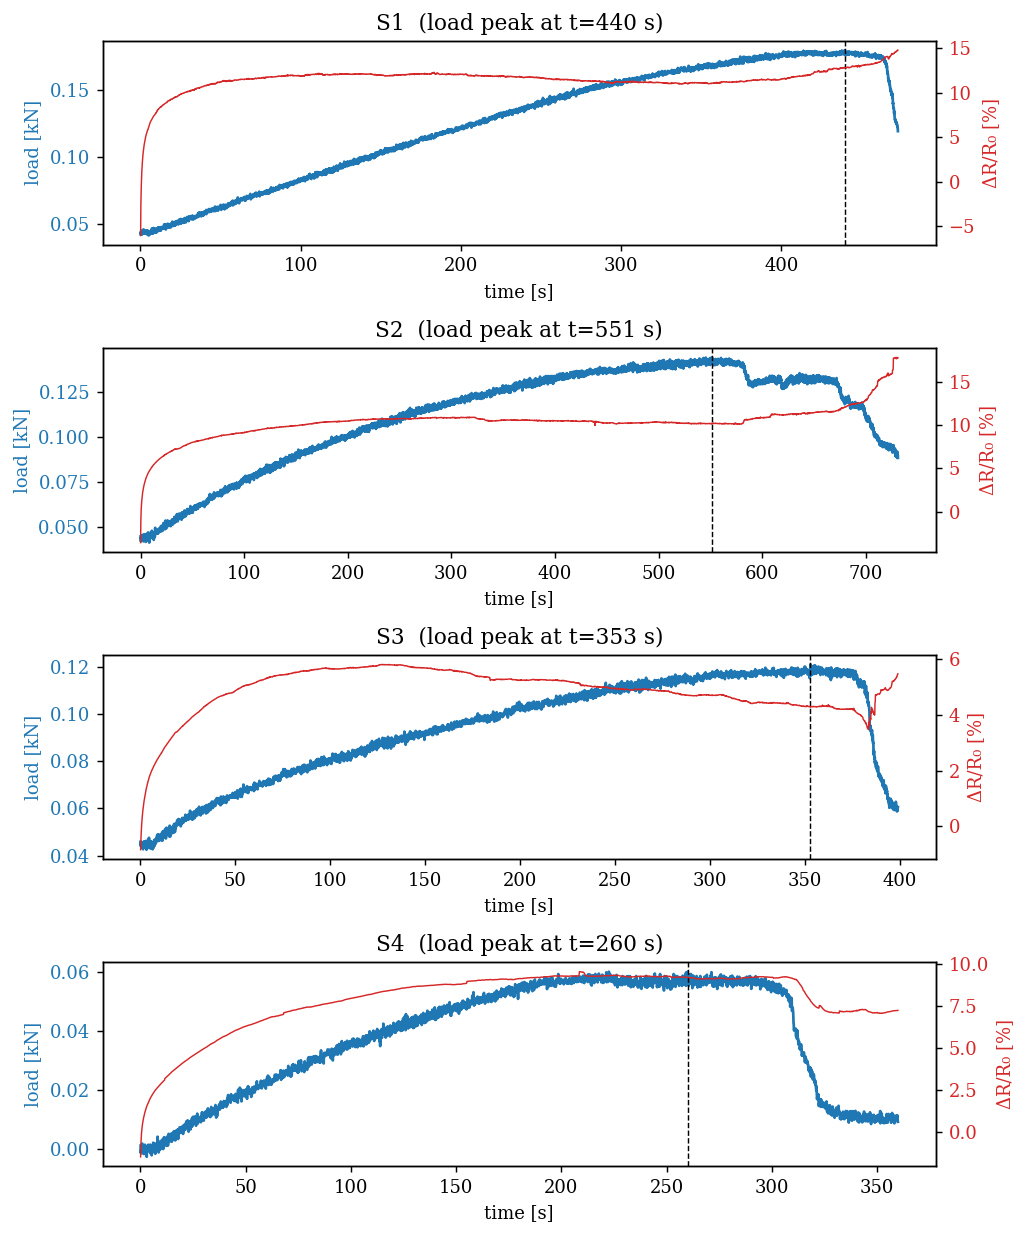

In [2]:
qa_figures.per_specimen_traces(df);

## Combined ΔR/R₀ vs deflection
All four bars should share the same qualitative shape despite the 8x spread in baseline R₀.

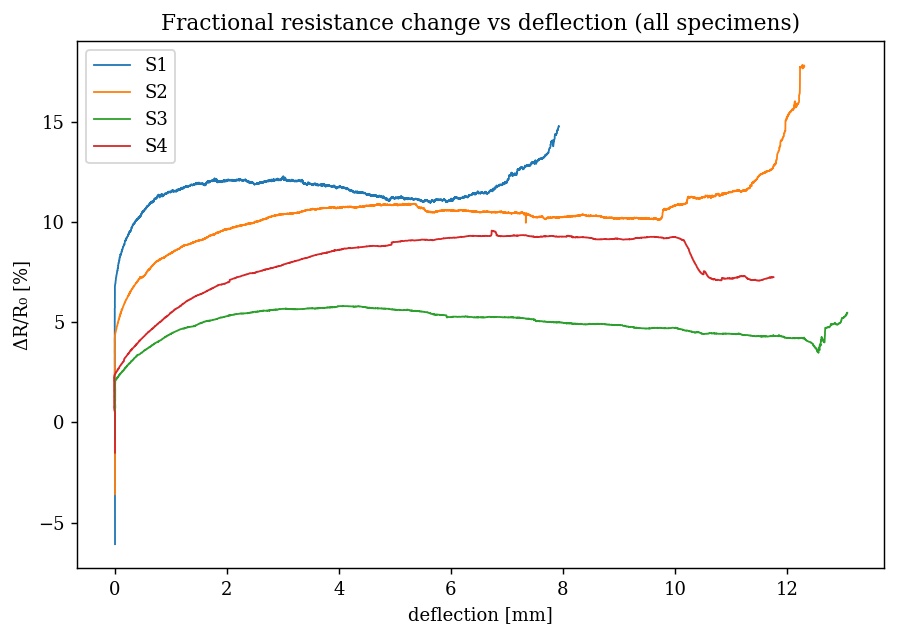

In [3]:
qa_figures.combined_fcr_vs_deflection(df);